<a href="https://colab.research.google.com/github/ajoven10/working-with-alphagenome/blob/notebooks/Relevancia_nucleotidos_shap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Highlighting important regions with in silico mutagenesis: SHAP vs ISM AlphaGenome

This notebook performs an interpretability analysis on a specific DNA sequence using the AlphaGenome API, employing two different methods: In-Silico Mutagenesis (ISM) and SHAP (SHapley Additive exPlanations).

The ultimate goal is to visualize and compare the contribution of each nucleotide position to the model's prediction.

Script Summary
1. **Setup and Data Loading**
Initialization: Imports necessary libraries (alphagenome, matplotlib, numpy, shap, etc.) and sets up the AlphaGenome API key.

Genome Load: Loads the UCSC hg38 genome FASTA file into memory using Biopython's SeqIO.

Target Interval: Defines a 2KB DNA sequence (sequence_interval) centered around a region on chr20 (3,753,000 to 3,753,400) to provide context for the model.

2. **In-Silico Mutagenesis (ISM)** Calculation
ISM Definition: Defines a central 256-base region (ism_interval) within the 2KB sequence for mutation.

Scoring: Configures a CenterMaskScorer to measure the difference in the DNASE accessibility prediction for the K562 cell line (EFO:0002067) when each base in the 256-base region is mutated.

Result: The dna_model.score_ism_variants is called to generate variant scores, which are then processed by ism.ism_matrix. The final Alphagenome contribution (resultado_alphagenome) is calculated as the sum of contributions across all base types for each position.

3. **SHAP Value Calculation (Model Interpretation)**
Background Data Generation:

Random Sampling: 10000 random 256-base sequences are extracted from chr20.

Padding/One-Hot: These sequences are padded to 2048 bases (dna_len) and one-hot encoded to create the background_data_flat.

K-Means: The background data is reduced using K-Means clustering (K=5) to select a representative sample (background_data_sample) for the SHAP explainer.

Prediction Function: A predict_function_for_shap is defined. This function:

*   Decodes the one-hot encoded input back into a nucleotide string.
*   Calls the AlphaGenome API (dna_model.predict_sequence) for each sequence.

*   Returns the sum of the values of the DNASE accessibility predictions for the K562 cell line.

Explainer Setup: A shap.KernelExplainer is initialized with the prediction function and the background data sample.

SHAP Calculation: explainer.shap_values(dna_flat) is called to calculate the SHAP values for the target 256-base sequence (also padded and one-hot encoded).

Result Processing: The resulting flat SHAP array (≈8192 values) is reshaped and summed across the 4 bases to yield a single contribution value per nucleotide position (shap_valores), focused only on the central 256-base region.

4. **Visualization**
Plotting: Both the ISM Alphagenome contributions (resultado_alphagenome) and the SHAP contributions (shap_valores) are plotted on the same graph for direct comparison.


In [1]:
# -*- coding: utf-8 -*-
"""
Created on Mon Oct  6 17:06:12 2025

@author: ajoven10@gmail.com
(I used gemini and copilot)
"""
from IPython.display import clear_output
! pip install alphagenome
clear_output()

In [2]:
! pip install Bio
clear_output()


## Imports

In [3]:
from alphagenome import colab_utils
from alphagenome.data import gene_annotation
from alphagenome.data import genome
from alphagenome.data import transcript as transcript_utils
from alphagenome.interpretation import ism
from alphagenome.models import dna_client
from alphagenome.models import variant_scorers
from alphagenome.visualization import plot_components
from alphagenome.data import track_data
import matplotlib.pyplot as plt
import pandas as pd
import os
from Bio import SeqIO
import numpy as np
import shap
import random
import gzip
import shutil
from IPython.display import display, HTML

In [4]:
dna_model = dna_client.create(colab_utils.get_api_key())

## Previously

The hg38 genome is downloaded:

In [5]:
url = "https://hgdownload.cse.ucsc.edu/goldenpath/hg38/bigZips/latest/hg38.fa.gz"
!wget {url}

archivo_gz="hg38.fa.gz"
archivo_fasta="hg38.fa"

with gzip.open(archivo_gz, 'rb') as f_in, open(archivo_fasta, 'wb') as f_out:
    shutil.copyfileobj(f_in, f_out)

clear_output()

In [6]:
def carga_genome():
    hg38_fasta = "/content/hg38.fa"  # Ruta al archivo FASTA
    genome = SeqIO.to_dict(SeqIO.parse(hg38_fasta, "fasta"))
    return(genome)

genoma = carga_genome()

## Working with alphagenome

Obtaining the relative nucleotide importance track for a 256-bp interval on chr20 3753328-3753584 with Alphagenome.

The steps from the [Aphagenome quick start notebook](https://www.alphagenomedocs.com/colabs/quick_start.html) are followed.

In [7]:
# 2KB DNA sequence to use as context when making predictions.
sequence_interval = genome.Interval('chr20', 3_753_000, 3_753_400)
sequence_interval = sequence_interval.resize(dna_client.SEQUENCE_LENGTH_2KB)

# Mutate all bases in the central 256-base region of the sequence_interval.
ism_interval = sequence_interval.resize(256)

dnase_variant_scorer = variant_scorers.CenterMaskScorer(
    requested_output=dna_client.OutputType.DNASE,
    width=501,
    aggregation_type=variant_scorers.AggregationType.DIFF_MEAN,
)

variant_scores = dna_model.score_ism_variants(
    interval=sequence_interval,
    ism_interval=ism_interval,
    variant_scorers=[dnase_variant_scorer],
)

def extract_k562(adata):
  values = adata.X[:, adata.var['ontology_curie'] == 'EFO:0002067']
  assert values.size == 1
  return values.flatten()[0]

ism_result = ism.ism_matrix(
    [extract_k562(x[0]) for x in variant_scores],
    variants=[v[0].uns['variant'] for v in variant_scores],
)

  0%|          | 0/26 [00:00<?, ?it/s]

Now, I sum the resulting ISM values by position.

In [8]:
resultado_alphagenome = np.sum(ism_result, axis=1)

## Working with Shap

###Background for SHAP

In this code snippet, DNA sequences are extracted from the previously downloaded genome, and 10000 random 256-bp sequences from chromosome chr20 will be obtained to provide background for SHAP.

In [9]:
CROMOSOMA = 'chr20'
LONGITUD_SECUENCIA = 256
NUM_SECUENCIAS = 10000

# Retrieve the chromosome 20 sequence.
secuencia_chr20 = genoma[CROMOSOMA].seq
longitud_chr20 = len(secuencia_chr20)

limite_superior = longitud_chr20 - LONGITUD_SECUENCIA
secuencias_aleatorias = []

# Generate and extract the 10000 sequences.
for i in range(NUM_SECUENCIAS):
    start = random.randint(0, limite_superior)
    end = start + LONGITUD_SECUENCIA
    sub_secuencia = str(secuencia_chr20[start:end])
    secuencias_aleatorias.append(sub_secuencia)

# The sequences are resized to a length of 2048 bp (base pairs).
registros_padded = [secu.center(2048, 'N') for secu in secuencias_aleatorias]

### The target DNA interval sequence is extracted.

The sequence defined by the ISM interval object is extracted from the genome for further processing.

In [10]:
dna = str(genoma[ism_interval.chromosome].seq[ism_interval.start:ism_interval.end])

### One-Hot-Encoding functions


The necessary functions are defined to convert DNA sequences into the one-hot encoding format required for calls to the SHAP functions.

In [11]:
def one_hot_encode_multiple_sequences(sequences):
    num_sequences = len(sequences)
    one_hot_array = np.zeros((num_sequences, len(sequences[0]), 4), dtype=np.int8)
    for i, seq in enumerate(sequences):
        for j, char in enumerate(seq):
            if char == "A" or char == "a": one_hot_array[i, j, 0] = 1
            elif char == "C" or char == "c": one_hot_array[i, j, 1] = 1
            elif char == "G" or char == "g": one_hot_array[i, j, 2] = 1
            elif char == "T" or char == "t": one_hot_array[i, j, 3] = 1
    return one_hot_array

def one_hot_encode_single_sequence(sequence):
    return one_hot_encode_multiple_sequences([sequence])


### Prediction function for SHAP analysis

Define the prediction function for SHAP analysis. This function should accept a data array in one-hot encoding format and return the model's predictions calculated as the sum of Shap values.

In [12]:
call_counter = 0

In [13]:
def predict_function_for_shap(one_hot_sequences_flat):
    """
    Prediction function for SHAP. It decodes the flat array, calls the API, and returns the prediction value.
    """
    global call_counter
    num_sequences = one_hot_sequences_flat.shape[0]
    one_hot_sequences_3d = one_hot_sequences_flat.reshape(num_sequences, dna_len, 4)

    predictions = []
    for one_hot_seq_3d in one_hot_sequences_3d:
        nucleotide_string = "".join(
            "A" if np.all(v == [1, 0, 0, 0]) else
            "C" if np.all(v == [0, 1, 0, 0]) else
            "G" if np.all(v == [0, 0, 1, 0]) else
            "T" if np.all(v == [0, 0, 0, 1]) else
            "N"
            for v in one_hot_seq_3d
        )

        result = dna_model.predict_sequence(
            sequence=nucleotide_string,
            requested_outputs=[dna_client.OutputType.DNASE],
            ontology_terms=ontology
        )
        # predictions.append(result.dnase.values[secuencia_len // 2])
        predictions.append(np.sum(result.dnase.values[896:1152]))
        # predictions.append(np.sum(np.abs(result.dnase.values)))
        call_counter += 1

    return np.array(predictions)

### The SHAP analysis is performed.

The sequence to be explained is prepared.

In [14]:
dna_len = 2048
ontology = ['EFO:0002067']
dna_padded = dna.center(2048, 'N')

# Encode the sequence to be explained and flatten it.
dna_one_hot = one_hot_encode_single_sequence(dna_padded)
dna_flat = dna_one_hot.reshape(1, -1)

K = 5 # background for shap

background_data_3d = one_hot_encode_multiple_sequences(registros_padded)
background_data_flat = background_data_3d.reshape(len(secuencias_aleatorias), -1)
background_sample_data = shap.kmeans(background_data_flat, K)
background_data_sample = background_sample_data.data


Running SHAP analysis: target sequence and background setup:

In [15]:
# Initialize
print("Calculating SHAP values. This may take time...")
explainer = shap.KernelExplainer(predict_function_for_shap, background_data_sample)
shap_values_flat = explainer.shap_values(dna_flat)
print(f"The AlphaGenome model was accessed {call_counter} times.")

Calculating SHAP values. This may take time...


  0%|          | 0/1 [00:00<?, ?it/s]

The AlphaGenome model was accessed 12806 times.


In [16]:
# Reorganize and visualize the values
# The shap_values_flat result will have a shape of (1, 8192)
# Therefore, we need to reshape the array to sum values by position
shap_values_3d = shap_values_flat.reshape(1, -1, 4)
# Now, sum the SHAP values of each base for every position.
shap_values_summed = shap_values_3d.sum(axis=-1).squeeze()
shap_valores = shap_values_summed[896:1152]


## Apply the AlphaGenome model to the target sequence

In [17]:
result = dna_model.predict_sequence(
    sequence=dna_padded,
    requested_outputs=[dna_client.OutputType.DNASE],
    ontology_terms=ontology
)
valores_alphagenome = result.dnase.values[896:1152].squeeze()


## Plots

### Plot of contributions per position according to AlphaGenome and SHAP

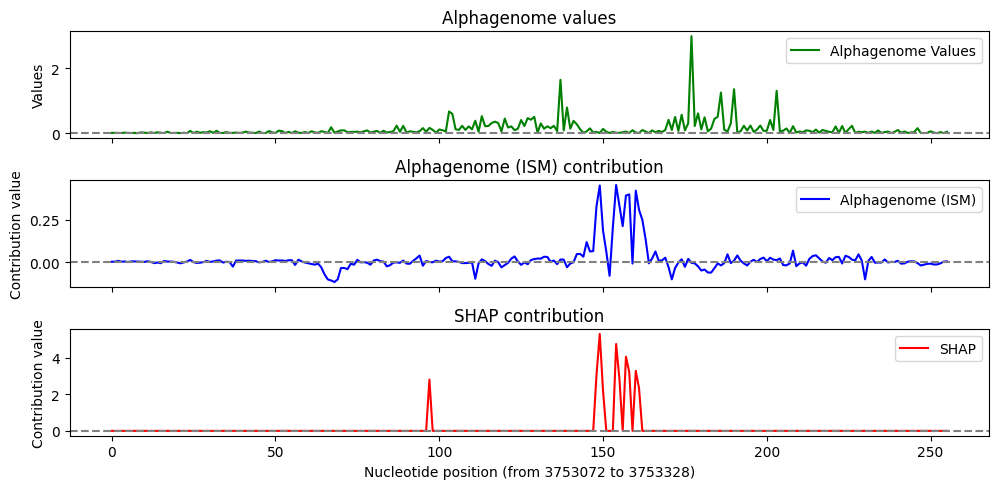

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(10, 5), sharex=True) # 2 filas, 1 columna, comparten el eje x

# Plot for AlphaGenome model values
axes[0].plot(valores_alphagenome, label='Alphagenome Values', color='green')
axes[0].set_title("Alphagenome values")
axes[0].axhline(y=0, color='grey', linestyle='--')
axes[0].set_ylabel("Values")
axes[0].legend()


# Gráfico para contribuciones posiciones Alphagenome (ISM)
axes[1].plot(resultado_alphagenome, label='Alphagenome (ISM)', color='blue')
axes[1].set_title("Alphagenome (ISM) contribution")
axes[1].axhline(y=0, color='grey', linestyle='--')
axes[1].set_ylabel("Contribution value")
axes[1].legend()

# Gráfico para SHAP
axes[2].plot(shap_valores, label='SHAP', color='red') # Color para SHAP
axes[2].set_title("SHAP contribution")
axes[2].axhline(y=0, color='grey', linestyle='--')
axes[2].set_xlabel(f"Nucleotide position (from {ism_interval.start} to {ism_interval.end})")
axes[2].set_ylabel("Contribution value")
axes[2].legend()

# Ajusta el layout para evitar superposiciones
plt.tight_layout()

plt.show()

A reasonable coincidence is observed between the values ​​of the contributions to the prediction obtained with AlphaGenome and those obtained with Shap.

### Plot of AlphaGenome tracks

In [19]:
from alphagenome.data import track_data, genome

gtf = pd.read_feather(
    'https://storage.googleapis.com/alphagenome/reference/gencode/'
    'hg38/gencode.v46.annotation.gtf.gz.feather'
)

# Set up transcript extractors using the information in the GTF file.
gtf_transcripts = gene_annotation.filter_protein_coding(gtf)
gtf_transcripts = gene_annotation.filter_to_longest_transcript(gtf_transcripts)
transcript_extractor = transcript_utils.TranscriptExtractor(gtf_transcripts)

longest_transcripts = transcript_extractor.extract(sequence_interval)



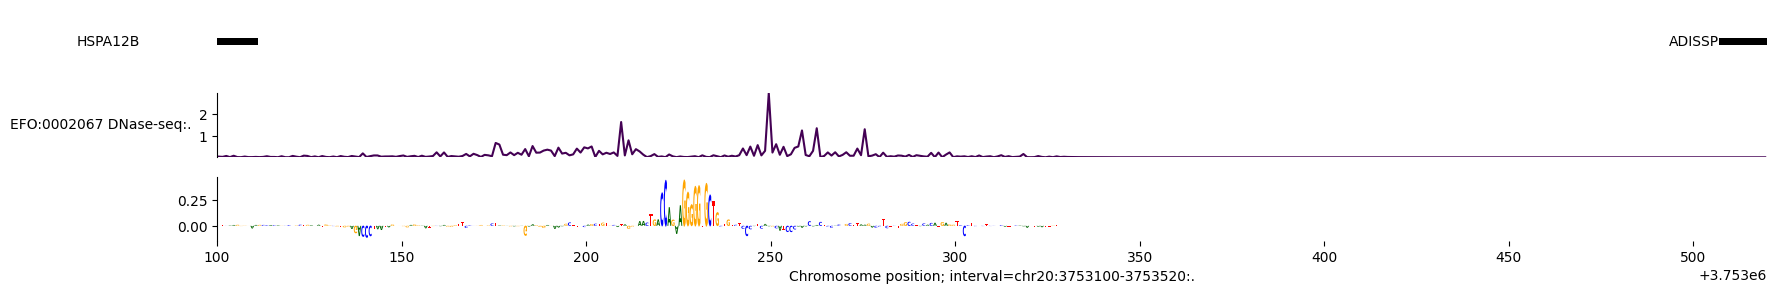

In [20]:
intervalo_plot = genome.Interval('chr20', 3_753_100, 3_753_520)

dnase_track = track_data.TrackData(
    values=result.dnase.values,
    metadata=result.dnase.metadata,
    interval=sequence_interval # Set the interval explicitly during creation
)

ism_metadata = pd.DataFrame({
    'name': ['A', 'C', 'G', 'T'],
    'strand': ['.', '.', '.', '.'] # Add the strand column
    })

ism_track_data = track_data.TrackData(
    values=ism_result, # ism_result should be (length, 4)
    metadata=ism_metadata, # Use the new metadata
    interval=ism_interval
)
plot_components.plot(
    components=[
        plot_components.TranscriptAnnotation(longest_transcripts),
        plot_components.Tracks(dnase_track),
        plot_components.SeqLogo(scores=ism_track_data.values, scores_interval=ism_track_data.interval) # Pass scores and scores_interval directly
    ],
    interval= intervalo_plot
)

plt.show()

In the graph showing the two tracks obtained with the alphagenome model, one with the model's prediction values ​​and the other with the values ​​of the contribution of each position to that prediction, it is surprising that the highest contributions do not correlate with the DNAse prediction values ​​and are located in a valley between two high prediction zones.

## Comparison of key positions: AlphaGenome vs SHAP relevance

In [21]:
top_10_alphagenome_contribuciones = np.argsort(resultado_alphagenome)[-10:]
top_10_shap_indices = np.argsort(shap_valores)[-10:]

print("Top 10 indices for Alphagenome (ISM):", top_10_alphagenome_contribuciones)
print("Top 10 indices for SHAP:", top_10_shap_indices)

common_indices = np.intersect1d(top_10_alphagenome_contribuciones, top_10_shap_indices)

print("Common indices in the top 10 for both methods:", common_indices)

Top 10 indices for Alphagenome (ISM): [156 162 161 148 155 157 158 160 149 154]
Top 10 indices for SHAP: [150 161  97 155 148 158 160 157 154 149]
Common indices in the top 10 for both methods: [148 149 154 155 157 158 160 161]


In [25]:
top_10_alphagenome_valores = np.argsort(valores_alphagenome)[-10:]
common_indices = np.intersect1d(top_10_alphagenome_contribuciones, top_20_alphagenome_valores)
print("Common indices in the top 10 for both:", common_indices)


Common indices in the top 10 for both: []


A high concordance is observed between the most relevant positions according to AlphaGenome ISM and Shap, just as the lack of concordance is observed again between the positions relevant to the model and the positions whose DNAse value prediction is higher.

In [26]:
dna_segment = dna

formatted_dna = []

for i in range(len(dna_segment)):
    index_in_ism = i
    nucleotide = dna_segment[i]
    color = 'black' # Default color
    font_size = '70%' # Default font size

    in_contribuciones = index_in_ism in top_10_alphagenome_contribuciones
    in_valores = index_in_ism in top_10_alphagenome_valores

    if in_contribuciones and in_valores:
        color = 'purple'
        font_size = '170%'
    elif in_contribuciones:
        # If only in top_10_alphagenome_contribuciones, highlight in red
        color = 'red'
        font_size = '170%'
    elif in_valores:
        # If only in top_10_alphagenome_valores, highlight in blue
        color = 'blue'
        font_size = '170%'

    # Apply HTML formatting
    formatted_nucleotide = f'<span style="color: {color}; font-size: {font_size};">{nucleotide}</span>'
    formatted_dna.append(formatted_nucleotide)

# Join the formatted nucleotides and display as HTML
html_output = "".join(formatted_dna)
display(HTML(f'<pre>{html_output}</pre>')) # Using <pre> to maintain spacing

The positions with the highest DNAse predictive value surround the most relevant positions for prediction purposes. Among the former, we observe a majority of A nucleotides, while in the latter, the majority corresponds to the G nucleotide.